In [8]:
# Cell 1 — Load + freeze the population-analysis cohort
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import rankdata, spearmanr, wilcoxon


def find_repo_root(start):
    for path in (start, *start.parents):
        if (path / "phase1" / "results").is_dir():
            return path
    raise FileNotFoundError("Repository root was not found.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
RESULT_DIR = REPO_ROOT / "phase1" / "results" / "lle" / "surrogates"
SUMMARY_PATTERN = re.compile(r"session_(\d+)_lle_pps_summary[.]csv$")
STATE_ORDER = ["Awake", "Drowsy"]
BOOTSTRAP_N = 20_000
RANDOM_SEED = 20260828
ALPHA = 0.05

summary_files = []
for path in RESULT_DIR.glob("session_*_lle_pps_summary.csv"):
    match = SUMMARY_PATTERN.match(path.name)
    if match:
        summary_files.append((int(match.group(1)), path))
summary_files.sort()
if not summary_files:
    raise FileNotFoundError(f"No validated LLE–PPS summaries found in {RESULT_DIR}.")

all_windows = pd.concat(
    [pd.read_csv(path) for _, path in summary_files], ignore_index=True
)
assert len(summary_files) == all_windows["session"].nunique() == 20
assert all_windows["representation"].str.casefold().eq("processed").all()
assert all_windows["window_size_s"].eq(60).all()
assert all_windows["n_surrogates_expected"].eq(39).all()
assert np.isfinite(all_windows["surrogate_lle_median"]).all()

all_windows["Delta_PPS"] = (
    all_windows["original_lle"] - all_windows["surrogate_lle_median"]
)
all_windows["state"] = pd.Categorical(
    all_windows["state"], categories=STATE_ORDER, ordered=True
)
finite_cohort = all_windows.loc[np.isfinite(all_windows["original_lle"])].copy()
primary_cohort = finite_cohort.loc[finite_cohort["original_valid"].astype(bool)].copy()
strict_r2_cohort = finite_cohort.loc[finite_cohort["original_fit_r2"] >= 0.95].copy()
excluded_from_primary = len(finite_cohort) - len(primary_cohort)

cohort_report = pd.DataFrame([
    {"cohort": "Primary: original_valid", "sessions": primary_cohort["session"].nunique(),
     "windows": len(primary_cohort), "Awake": primary_cohort["state"].eq("Awake").sum(),
     "Drowsy": primary_cohort["state"].eq("Drowsy").sum()},
    {"cohort": "Sensitivity: all finite", "sessions": finite_cohort["session"].nunique(),
     "windows": len(finite_cohort), "Awake": finite_cohort["state"].eq("Awake").sum(),
     "Drowsy": finite_cohort["state"].eq("Drowsy").sum()},
    {"cohort": "Sensitivity: original R² >= 0.95", "sessions": strict_r2_cohort["session"].nunique(),
     "windows": len(strict_r2_cohort), "Awake": strict_r2_cohort["state"].eq("Awake").sum(),
     "Drowsy": strict_r2_cohort["state"].eq("Drowsy").sum()},
])
display(cohort_report)
print(f"Excluded from primary by original QC: {excluded_from_primary}")

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})


,cohort,sessions,windows,Awake,Drowsy
0,Primary: original_valid,20,872,579,293
1,Sensitivity: all finite,20,901,596,305
2,Sensitivity: original R² >= 0.95,20,734,500,234


Excluded from primary by original QC: 29


,group,n_windows,median_Delta_PPS,Q25,Q75,IQR,minimum,maximum,fraction_positive,fraction_negative,rank_rejection_rate,higher_direction_rate
0,Overall,872,0.213519,0.169667,0.264878,0.095210,0.016856,0.468234,1.0,0.0,0.954128,0.954128
1,Awake,579,0.216536,0.174272,0.271556,0.097284,0.016856,0.468234,1.0,0.0,0.941278,0.941278
2,Drowsy,293,0.207853,0.160920,0.251803,0.090883,0.049670,0.444608,1.0,0.0,0.979522,0.979522


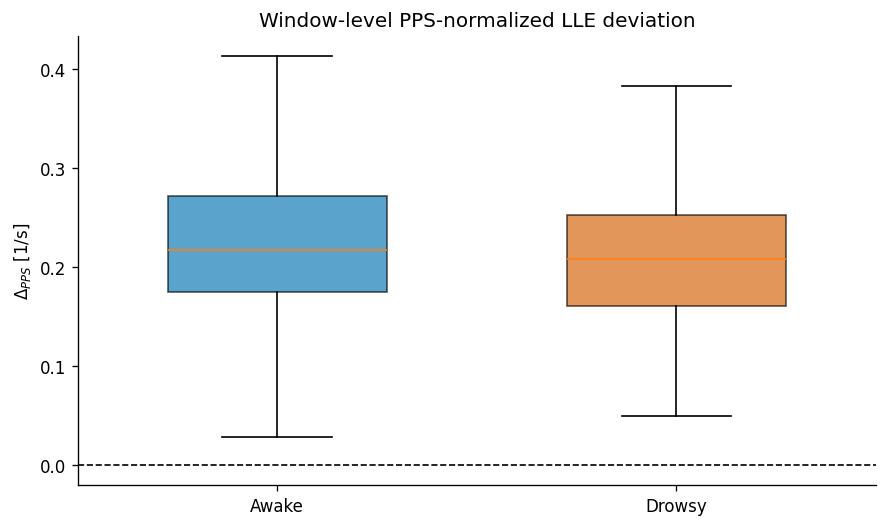

Window-level quantities are descriptive; no window-level inference is performed.


In [9]:
# Cell 2 — Window-level population description (descriptive only)
def describe_windows(frame, label):
    values = frame["Delta_PPS"].to_numpy(dtype=float)
    q25, median, q75 = np.quantile(values, [0.25, 0.50, 0.75])
    return {
        "group": label, "n_windows": len(frame),
        "median_Delta_PPS": median, "Q25": q25, "Q75": q75,
        "IQR": q75 - q25, "minimum": values.min(), "maximum": values.max(),
        "fraction_positive": np.mean(values > 0),
        "fraction_negative": np.mean(values < 0),
        "rank_rejection_rate": frame["reject_alpha_0_05"].astype(bool).mean(),
        "higher_direction_rate": frame["rank_direction"].eq("higher").mean(),
    }


window_description = pd.DataFrame([
    describe_windows(primary_cohort, "Overall"),
    describe_windows(primary_cohort[primary_cohort["state"].eq("Awake")], "Awake"),
    describe_windows(primary_cohort[primary_cohort["state"].eq("Drowsy")], "Drowsy"),
])
display(window_description.round(6))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_data = [
    primary_cohort.loc[primary_cohort["state"].eq(state), "Delta_PPS"].to_numpy()
    for state in STATE_ORDER
]
boxes = ax.boxplot(plot_data, tick_labels=STATE_ORDER, patch_artist=True, widths=0.55, showfliers=False)
for patch, color in zip(boxes["boxes"], ["#0072B2", "#D55E00"]):
    patch.set_facecolor(color); patch.set_alpha(0.65)
ax.axhline(0, color="black", ls="--", lw=1)
ax.set(title="Window-level PPS-normalized LLE deviation", ylabel=r"$\Delta_{PPS}$ [1/s]")
fig.tight_layout()
plt.show()
print("Window-level quantities are descriptive; no window-level inference is performed.")


,session,state,median_original_LLE,median_PPS_LLE,median_Delta_PPS,n_windows,fraction_positive,rank_rejection_rate
0,1,Awake,0.936381,0.593062,0.341754,24,1.0,1.000000
1,1,Drowsy,0.850845,0.596536,0.256527,7,1.0,1.000000
2,4,Awake,0.808205,0.599588,0.209302,29,1.0,0.931034
3,4,Drowsy,0.758851,0.596848,0.162499,17,1.0,1.000000
4,5,Awake,0.762883,0.501593,0.256679,33,1.0,1.000000
5,5,Drowsy,0.694129,0.472570,0.206748,16,1.0,0.875000
6,6,Awake,0.825690,0.637719,0.190182,30,1.0,1.000000
7,6,Drowsy,0.804640,0.618624,0.205901,17,1.0,1.000000
8,7,Awake,0.857377,0.605845,0.238694,34,1.0,0.970588
9,7,Drowsy,0.804350,0.546624,0.254705,10,1.0,1.000000


,sessions,positive_sessions,negative_sessions,median_across_sessions,Q25,Q75,IQR
0,20,20,0,0.206525,0.186639,0.243097,0.056458


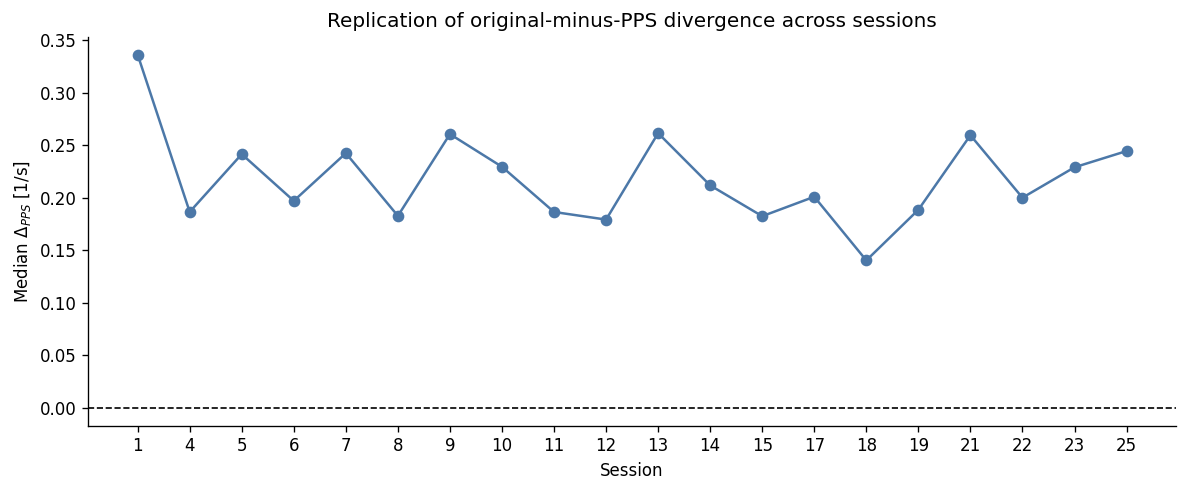

In [10]:
# Cell 3 — Session-level PPS deviation
session_state = (
    primary_cohort.groupby(["session", "state"], observed=True, as_index=False)
    .agg(
        median_original_LLE=("original_lle", "median"),
        median_PPS_LLE=("surrogate_lle_median", "median"),
        median_Delta_PPS=("Delta_PPS", "median"),
        n_windows=("window_id", "size"),
        fraction_positive=("Delta_PPS", lambda x: np.mean(x > 0)),
        rank_rejection_rate=("reject_alpha_0_05", "mean"),
    )
)
session_overall = (
    primary_cohort.groupby("session", as_index=False)
    .agg(
        median_Delta_PPS=("Delta_PPS", "median"),
        n_windows=("window_id", "size"),
        fraction_positive=("Delta_PPS", lambda x: np.mean(x > 0)),
        rank_rejection_rate=("reject_alpha_0_05", "mean"),
    )
)
session_q25, session_median, session_q75 = np.quantile(
    session_overall["median_Delta_PPS"], [0.25, 0.50, 0.75]
)
session_replication_report = pd.DataFrame([{
    "sessions": len(session_overall),
    "positive_sessions": int((session_overall["median_Delta_PPS"] > 0).sum()),
    "negative_sessions": int((session_overall["median_Delta_PPS"] < 0).sum()),
    "median_across_sessions": session_median,
    "Q25": session_q25, "Q75": session_q75, "IQR": session_q75 - session_q25,
}])
display(session_state.round(6))
display(session_replication_report.round(6))

fig, ax = plt.subplots(figsize=(10, 4.2))
x = np.arange(len(session_overall))
ax.plot(x, session_overall["median_Delta_PPS"], marker="o", color="#4C78A8")
ax.axhline(0, color="black", ls="--", lw=1)
ax.set(xticks=x, xticklabels=session_overall["session"].astype(int),
       xlabel="Session", ylabel=r"Median $\Delta_{PPS}$ [1/s]",
       title="Replication of original-minus-PPS divergence across sessions")
fig.tight_layout()
plt.show()


In [11]:
# Cell 4 — Primary population inference: one median Delta_PPS per session
def percentile_bootstrap_median(values, n_bootstrap=BOOTSTRAP_N, seed=RANDOM_SEED):
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or values.size == 0 or not np.all(np.isfinite(values)):
        raise ValueError("Bootstrap input must be a finite non-empty 1D array.")
    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(n_bootstrap, values.size), replace=True)
    return np.quantile(np.median(samples, axis=1), [0.025, 0.975])


def matched_rank_biserial(values):
    values = np.asarray(values, dtype=float)
    nonzero = values[values != 0]
    if nonzero.size == 0:
        return 0.0
    ranks = rankdata(np.abs(nonzero), method="average")
    positive = ranks[nonzero > 0].sum()
    negative = ranks[nonzero < 0].sum()
    return float((positive - negative) / (positive + negative))


def one_sample_session_inference(values, seed):
    values = np.asarray(values, dtype=float)
    ci_low, ci_high = percentile_bootstrap_median(values, seed=seed)
    test = wilcoxon(values, zero_method="wilcox", alternative="two-sided", method="auto")
    return {
        "n_sessions": values.size, "median": float(np.median(values)),
        "ci_low": float(ci_low), "ci_high": float(ci_high),
        "wilcoxon_statistic": float(test.statistic), "wilcoxon_p": float(test.pvalue),
        "rank_biserial": matched_rank_biserial(values),
        "positive_sessions": int(np.sum(values > 0)),
        "negative_sessions": int(np.sum(values < 0)),
        "zero_sessions": int(np.sum(values == 0)),
    }


primary_inference = one_sample_session_inference(
    session_overall["median_Delta_PPS"].to_numpy(), seed=RANDOM_SEED
)
display(pd.DataFrame([primary_inference]).round(8))
print("H0: the session-level median PPS-normalized LLE deviation is centered at zero.")


,n_sessions,median,ci_low,ci_high,wilcoxon_statistic,wilcoxon_p,rank_biserial,positive_sessions,negative_sessions,zero_sessions
0,20,0.206525,0.187679,0.242128,0.0,0.000002,1.0,20,0,0


H0: the session-level median PPS-normalized LLE deviation is centered at zero.


In [12]:
# Cell 5 — Paired Awake vs Drowsy PPS-normalized difference
state_pivot = session_state.pivot(
    index="session", columns="state", values="median_Delta_PPS"
).dropna(subset=STATE_ORDER)
state_pivot["Delta_state"] = state_pivot["Drowsy"] - state_pivot["Awake"]
state_inference = one_sample_session_inference(
    state_pivot["Delta_state"].to_numpy(), seed=RANDOM_SEED + 1
)
state_result = {
    "paired_sessions": len(state_pivot),
    "Awake_session_median_Delta_PPS": float(state_pivot["Awake"].median()),
    "Drowsy_session_median_Delta_PPS": float(state_pivot["Drowsy"].median()),
    "median_Delta_state": state_inference["median"],
    "ci_low": state_inference["ci_low"], "ci_high": state_inference["ci_high"],
    "wilcoxon_p": state_inference["wilcoxon_p"],
    "rank_biserial": state_inference["rank_biserial"],
    "positive_sessions": state_inference["positive_sessions"],
    "negative_sessions": state_inference["negative_sessions"],
}
display(state_pivot.reset_index().round(6))
display(pd.DataFrame([state_result]).round(8))
print("Delta_state < 0: Drowsy has less excess divergence above PPS; Delta_state > 0: greater excess.")


state,session,Awake,Drowsy,Delta_state
0,1,0.341754,0.256527,-0.085228
1,4,0.209302,0.162499,-0.046804
2,5,0.256679,0.206748,-0.049931
3,6,0.190182,0.205901,0.015719
4,7,0.238694,0.254705,0.016011
5,8,0.178222,0.195011,0.016789
6,9,0.263417,0.207168,-0.056249
7,10,0.230923,0.199702,-0.031220
8,11,0.190797,0.181522,-0.009275
9,12,0.169824,0.181760,0.011936


,paired_sessions,Awake_session_median_Delta_PPS,Drowsy_session_median_Delta_PPS,median_Delta_state,ci_low,ci_high,wilcoxon_p,rank_biserial,positive_sessions,negative_sessions
0,20,0.211331,0.204356,0.012267,-0.027539,0.0164,0.840822,-0.057143,11,9


Delta_state < 0: Drowsy has less excess divergence above PPS; Delta_state > 0: greater excess.


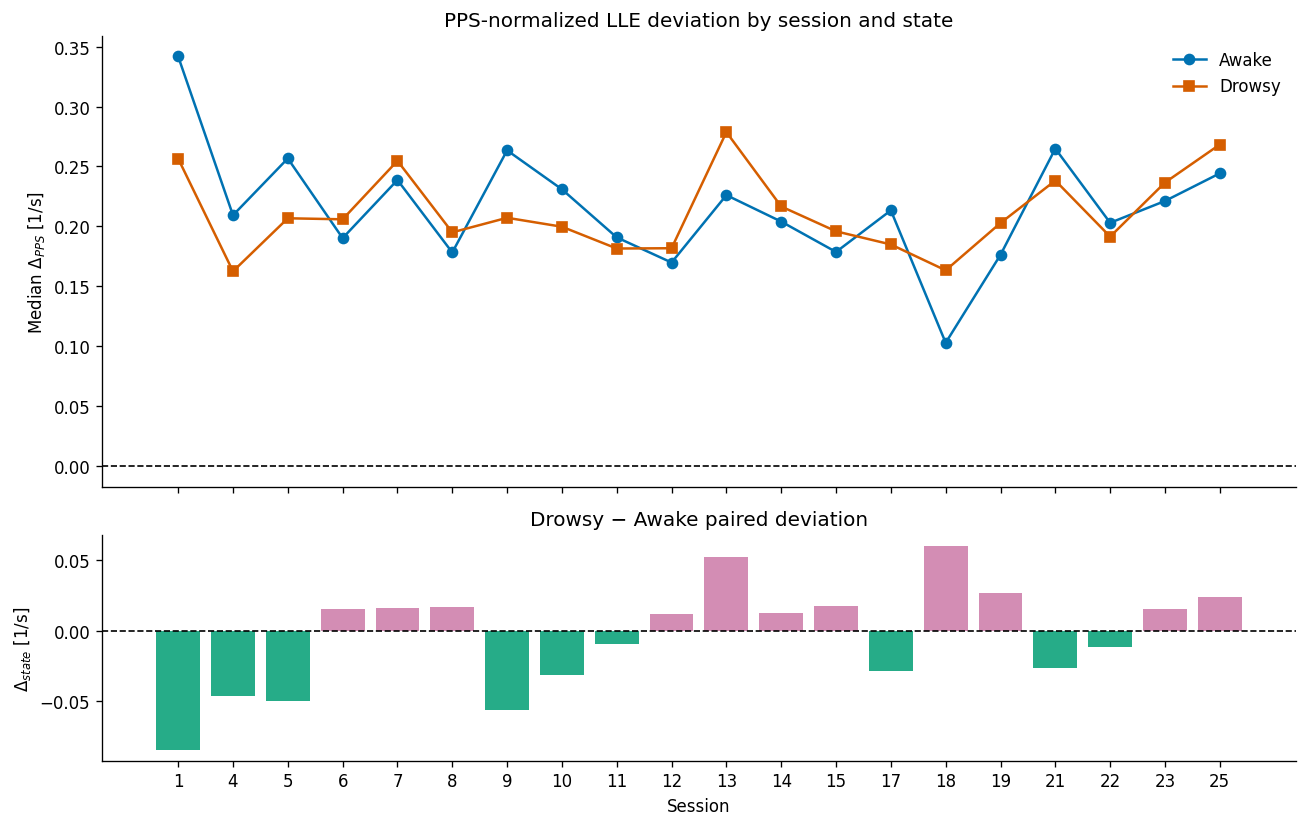

In [13]:
# Cell 6 — Publication-oriented session replication figure
plot_sessions = state_pivot.index.to_numpy(dtype=int)
x = np.arange(len(plot_sessions))
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(x, state_pivot["Awake"], marker="o", color="#0072B2", label="Awake")
axes[0].plot(x, state_pivot["Drowsy"], marker="s", color="#D55E00", label="Drowsy")
axes[0].axhline(0, color="black", ls="--", lw=1)
axes[0].set(ylabel=r"Median $\Delta_{PPS}$ [1/s]", title="PPS-normalized LLE deviation by session and state")
axes[0].legend(frameon=False)
bar_colors = np.where(state_pivot["Delta_state"] >= 0, "#CC79A7", "#009E73")
axes[1].bar(x, state_pivot["Delta_state"], color=bar_colors, alpha=0.85)
axes[1].axhline(0, color="black", ls="--", lw=1)
axes[1].set(xticks=x, xticklabels=plot_sessions, xlabel="Session",
            ylabel=r"$\Delta_{state}$ [1/s]", title="Drowsy − Awake paired deviation")
fig.tight_layout()
plt.show()


In [14]:
# Cell 7 — Rank/deviation concordance (supporting descriptive evidence)
session_evidence = (
    primary_cohort.groupby("session", as_index=False)
    .agg(
        median_Delta_PPS=("Delta_PPS", "median"),
        rejection_rate=("reject_alpha_0_05", "mean"),
        higher_direction_rate=("rank_direction", lambda x: x.eq("higher").mean()),
        n_windows=("window_id", "size"),
    )
)
if session_evidence["rejection_rate"].nunique() > 1:
    spearman_rejection = spearmanr(
        session_evidence["median_Delta_PPS"], session_evidence["rejection_rate"]
    )
else:
    spearman_rejection = type("Result", (), {"statistic": np.nan, "pvalue": np.nan})()
concordance_report = pd.DataFrame([{
    "sessions": len(session_evidence),
    "rejection_rate_min": session_evidence["rejection_rate"].min(),
    "rejection_rate_max": session_evidence["rejection_rate"].max(),
    "higher_direction_rate_min": session_evidence["higher_direction_rate"].min(),
    "higher_direction_rate_max": session_evidence["higher_direction_rate"].max(),
    "spearman_rho": float(spearman_rejection.statistic),
    "spearman_p_descriptive": float(spearman_rejection.pvalue),
}])
display(session_evidence.round(6))
display(concordance_report.round(8))
print("Spearman correlation is descriptive and is not a primary inferential test.")


,session,median_Delta_PPS,rejection_rate,higher_direction_rate,n_windows
0,1,0.336363,1.000000,1.000000,31
1,4,0.186650,0.956522,0.956522,46
2,5,0.241661,0.959184,0.959184,49
3,6,0.197183,1.000000,1.000000,47
4,7,0.242595,0.977273,0.977273,44
5,8,0.182880,0.913043,0.913043,46
6,9,0.260758,1.000000,1.000000,57
7,10,0.229623,0.972222,0.972222,36
8,11,0.186606,1.000000,1.000000,37
9,12,0.179355,0.886792,0.886792,53


,sessions,rejection_rate_min,rejection_rate_max,higher_direction_rate_min,higher_direction_rate_max,spearman_rho,spearman_p_descriptive
0,20,0.815789,1.0,0.815789,1.0,0.574259,0.008097


Spearman correlation is descriptive and is not a primary inferential test.


In [15]:
# Cell 8 — QC sensitivity using the same session-level rules
def analyze_cohort(frame, cohort_name, seed):
    session_values = frame.groupby("session")["Delta_PPS"].median()
    overall = one_sample_session_inference(session_values.to_numpy(), seed=seed)
    state_values = (
        frame.groupby(["session", "state"], observed=True)["Delta_PPS"].median()
        .unstack("state").dropna(subset=STATE_ORDER)
    )
    paired = state_values["Drowsy"] - state_values["Awake"]
    state = one_sample_session_inference(paired.to_numpy(), seed=seed + 1)
    return {
        "cohort": cohort_name, "n_windows": len(frame),
        "overall_sessions": overall["n_sessions"],
        "overall_median": overall["median"],
        "overall_ci_low": overall["ci_low"], "overall_ci_high": overall["ci_high"],
        "overall_p": overall["wilcoxon_p"], "overall_r_rb": overall["rank_biserial"],
        "overall_positive": overall["positive_sessions"], "overall_negative": overall["negative_sessions"],
        "paired_sessions": state["n_sessions"], "median_Delta_state": state["median"],
        "state_ci_low": state["ci_low"], "state_ci_high": state["ci_high"],
        "state_p": state["wilcoxon_p"], "state_r_rb": state["rank_biserial"],
        "state_positive": state["positive_sessions"], "state_negative": state["negative_sessions"],
    }


sensitivity_results = pd.DataFrame([
    analyze_cohort(primary_cohort, "Primary: original_valid", RANDOM_SEED),
    analyze_cohort(finite_cohort, "Sensitivity: all finite", RANDOM_SEED + 10),
    analyze_cohort(strict_r2_cohort, "Sensitivity: original R² >= 0.95", RANDOM_SEED + 20),
])
display(sensitivity_results.round(8))


,cohort,n_windows,overall_sessions,overall_median,overall_ci_low,overall_ci_high,overall_p,overall_r_rb,overall_positive,overall_negative,paired_sessions,median_Delta_state,state_ci_low,state_ci_high,state_p,state_r_rb,state_positive,state_negative
0,Primary: original_valid,872,20,0.206525,0.187679,0.242128,0.000002,1.0,20,0,20,0.012267,-0.027539,0.016400,0.840822,-0.057143,11,9
1,Sensitivity: all finite,901,20,0.201022,0.186555,0.240999,0.000002,1.0,20,0,20,0.008962,-0.029837,0.016396,0.647655,-0.123810,11,9
2,Sensitivity: original R² >= 0.95,734,20,0.210822,0.195027,0.241398,0.000002,1.0,20,0,20,0.012346,-0.021068,0.022638,0.812355,0.066667,12,8


# Population-Level LLE–PPS Results

## Cohort

- Sessions: **20**
- Primary valid windows: **872**
- Awake / Drowsy: **579 / 293**
- PPS realizations per window: **39**
- Sensitivity cohorts: **901 all-finite windows** and **734 windows with original `R² ≥ 0.95`**

## Overall deviation from PPS

- Median window-level `Delta_PPS`: **0.21352 1/s**; IQR **0.16967–0.26488 1/s**
- Fraction `Delta_PPS > 0`: **100%**
- Window rank-test rejection and higher-direction rate: **95.41%**
- Sessions with positive median `Delta_PPS`: **20/20**

### Primary session-level inference

- Median session `Delta_PPS`: **0.20653 1/s**
- 95% percentile-bootstrap CI: **[0.18768, 0.24213] 1/s**
- Wilcoxon signed-rank: **p = 1.91×10⁻⁶**
- Matched-pairs rank-biserial: **r_rb = 1.000**
- Positive / negative sessions: **20 / 0**

> Observed Processed PPG exhibits greater local trajectory divergence than the matched noisy pseudoperiodic PPS null at the population level.

## State dependence

| State | Median of session-level `Delta_PPS` |
|---|---:|
| Awake | 0.21133 1/s |
| Drowsy | 0.20436 1/s |

Paired Drowsy − Awake:

- Median `Delta_state`: **0.01227 1/s**
- 95% percentile-bootstrap CI: **[−0.02754, 0.01640] 1/s**
- Wilcoxon: **p = 0.84082**
- Rank-biserial: **r_rb = −0.0571**
- Positive / negative sessions: **11 / 9**

> The paired analysis shows no clear Awake–Drowsy change in excess local divergence relative to the PPS null.

## Session replication

- Original > PPS at the session-median level: **20/20 sessions**
- Session median `Delta_PPS` range: **0.14050–0.33636 1/s**
- Awake–Drowsy direction: **11 positive and 9 negative paired sessions**
- Paired `Delta_state` range: **−0.08523–0.06046 1/s**

## Rank/deviation concordance

- Session rejection-rate range: **81.58–100%**
- Session higher-direction-rate range: **81.58–100%**
- Spearman relation between session median `Delta_PPS` and rejection rate: **ρ = 0.5743**, descriptive **p = 0.00810**
- Continuous `Delta_PPS` remains positive in every session, independent of the discrete `p=0.05` window boundary.

## QC sensitivity

| Cohort | Windows | Overall median (95% CI) | Overall r_rb | Median Drowsy−Awake (95% CI) | State p |
|---|---:|---:|---:|---:|---:|
| Primary valid | 872 | 0.20653 [0.18768, 0.24213] | 1.000 | 0.01227 [−0.02754, 0.01640] | 0.84082 |
| All finite | 901 | 0.20102 [0.18655, 0.24100] | 1.000 | 0.00896 [−0.02984, 0.01640] | 0.64766 |
| Original R² ≥ 0.95 | 734 | 0.21082 [0.19503, 0.24140] | 1.000 | 0.01235 [−0.02107, 0.02264] | 0.81236 |

The positive overall PPS deviation and the absence of a clear paired state effect are stable across the frozen sensitivity cohorts.

## Scientific conclusion

> Rosenstein LLE in observed Processed PPG systematically deviates from the matched PPS surrogate population, indicating local trajectory-divergence structure not captured by the tested noisy pseudoperiodic null.

The PPS-normalized analysis does not provide a clear paired Awake–Drowsy difference, despite the independently observed reduction in raw Rosenstein LLE during drowsiness.

> These results strengthen evidence for nonlinear dynamical organization but do not by themselves establish deterministic chaos.

## Next step

`integrate LLE–PPS with Nonlinear Prediction + RQA surrogate findings`
